## CAA Analysis: relationship with VAD and discrete emotions

### 1. VAD clustering analysis

Below list shows the Plutchik's wheel of emotions:
- joy
- trust
- anticipation
- surprise
- fear
- anger
- sadness
- disgust

Based on this, we want to see the distribution of each named emotion in our [database](../dataset/rewrites/affective_rewrites.csv), and see if we can find entries that correspond to these named emotions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

In [2]:

# categorise each entry in the dataset by its VAD values and map them to discrete emotions

VAD_PLUTCHIK_MAPPING = {
    "joy": {"valence": (0.75, 1.0), "arousal": (0.60, 1.0), "dominance": (0.60, 1.0)},
    "trust": {"valence": (0.70, 1.0), "arousal": (0.30, 0.60), "dominance": (0.60, 1.0)},
    "anticipation": {"valence": (0.55, 0.80), "arousal": (0.60, 1.0), "dominance": (0.50, 0.80)},
    "surprise": {"valence": (0.40, 0.60), "arousal": (0.80, 1.0), "dominance": (0.40, 0.60)},
    "fear": {"valence": (0.00, 0.30), "arousal": (0.70, 1.0), "dominance": (0.00, 0.40)},
    "anger": {"valence": (0.00, 0.30), "arousal": (0.70, 1.0), "dominance": (0.60, 1.0)},
    "sadness": {"valence": (0.00, 0.30), "arousal": (0.00, 0.40), "dominance": (0.00, 0.40)},
    "disgust": {"valence": (0.00, 0.30), "arousal": (0.30, 0.70), "dominance": (0.40, 0.80)},
}   
CSV_PATH = "../dataset/rewrites/affective_rewrites.csv"
LEXICON_PATH = "../dataset/vad_lexicons/lex.csv"

df_raw = pd.read_csv(CSV_PATH, header=0)
vad_lexicon = pd.read_csv(LEXICON_PATH)

COLUMNS = [
    "source_dataset", "source_split", "source_id",
    "base_text", "positive_rewrite", "negative_rewrite",
    "preserved_meaning_score",
    "positive_description", "negative_description",
    "base_valence", "base_arousal", "base_dominance",
    "positive_valence", "positive_arousal", "positive_dominance",
    "negative_valence", "negative_arousal", "negative_dominance",
]

VAD_COLS = COLUMNS[10:]  # all 9 numeric VAD scores

df = df_raw.copy()
df.columns = COLUMNS

# Build lex_lookup and lex_dict from vad_lexicon (Warriner norms, scale 1-9 → 0-1)
lex_lookup = pd.DataFrame({
    "word": vad_lexicon["Word"].str.lower(),
    "valence": (vad_lexicon["V.Mean.Sum"] - 1) / 8,
    "arousal": (vad_lexicon["A.Mean.Sum"] - 1) / 8,
    "dominance": (vad_lexicon["D.Mean.Sum"] - 1) / 8,
}).reset_index(drop=True)

lex_dict = {
    row["word"]: {"valence": row["valence"], "arousal": row["arousal"], "dominance": row["dominance"]}
    for _, row in lex_lookup.iterrows()
}


In [3]:
# Use stricter thresholds to remove more neutral words
valence_threshold = 0.1  # Remove words with valence between 0.45 and 0.55
arousal_threshold = 0.1  # Remove words with arousal between 0.45 and 0.55
dominance_threshold = 0.1  # Remove words with dominance between 0.45 and 0.55

# also use suffix filtering to remove noun
SUFFIXES_TO_REMOVE = ["ion", "ment", "ness", "ity", "ship", "age", "ery", "ance", "ence", "hood", "ism", "ist", "ity", "ty"]

# Filter out emotionally weak words
lex_dict_filtered = {
    word: vad for word, vad in lex_dict.items()
    if not (
        (0.5 - valence_threshold < vad['valence'] < 0.5 + valence_threshold) or
        (0.5 - arousal_threshold < vad['arousal'] < 0.5 + arousal_threshold) or
        (0.5 - dominance_threshold < vad['dominance'] < 0.5 + dominance_threshold)
    )
}

# Also filter the lookup dataframe
lex_lookup_filtered = lex_lookup[
    ~(
        (0.5 - valence_threshold < lex_lookup['valence']) & (lex_lookup['valence'] < 0.5 + valence_threshold) |
        (0.5 - arousal_threshold < lex_lookup['arousal']) & (lex_lookup['arousal'] < 0.5 + arousal_threshold) |
        (0.5 - dominance_threshold < lex_lookup['dominance']) & (lex_lookup['dominance'] < 0.5 + dominance_threshold)
    )
]

# Remove words with certain suffixes
lex_dict_filtered = {
    word: vad for word, vad in lex_dict_filtered.items()
    if not any(word.endswith(suffix) for suffix in SUFFIXES_TO_REMOVE)
}

print(f"Original lexicon size: {len(lex_dict)}")
print(f"Filtered lexicon size: {len(lex_dict_filtered)}")
print(f"Removed {len(lex_dict) - len(lex_dict_filtered)} weak words")

print("\nSample of filtered lexicon:")
for i, (word, vad) in enumerate(lex_dict_filtered.items()):
    if i >= 10:
        break
    print(f"{word}: {vad}")


Original lexicon size: 13905
Filtered lexicon size: 1758
Removed 12147 weak words

Sample of filtered lexicon:
abandon: {'valence': 0.22999999999999998, 'arousal': 0.34125, 'dominance': 0.29}
abduct: {'valence': 0.1775, 'arousal': 0.6125, 'dominance': 0.21875}
able: {'valence': 0.705, 'arousal': 0.2975, 'dominance': 0.64625}
abort: {'valence': 0.2625, 'arousal': 0.6, 'dominance': 0.2975}
abscess: {'valence': 0.22375, 'arousal': 0.375, 'dominance': 0.36875}
absinthe: {'valence': 0.31625, 'arousal': 0.3375, 'dominance': 0.36875}
abuse: {'valence': 0.06625, 'arousal': 0.65125, 'dominance': 0.2375}
abysmal: {'valence': 0.30625, 'arousal': 0.36375, 'dominance': 0.345}
academic: {'valence': 0.70125, 'arousal': 0.29, 'dominance': 0.65125}
accelerate: {'valence': 0.6375, 'arousal': 0.63, 'dominance': 0.64375}


In [4]:
import re

word_pattern = re.compile(r"[a-z]+(?:'[a-z]+)?")

def text_to_keyword_vad(text, lexicon=lex_dict_filtered):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan, np.nan, 0, []])

    tokens = word_pattern.findall(str(text).lower())
    matched_words = [tok for tok in tokens if tok in lexicon]

    if not matched_words:
        return pd.Series([np.nan, np.nan, np.nan, 0, []])

    scores = np.array([
        [lexicon[w]["valence"], lexicon[w]["arousal"], lexicon[w]["dominance"]]
        for w in matched_words
    ], dtype=float)

    return pd.Series([
        scores[:, 0].mean(),
        scores[:, 1].mean(),
        scores[:, 2].mean(),
        len(matched_words),
        matched_words,
    ])

for text_col, prefix in [
    ("base_text", "base_kw"),
    ("positive_rewrite", "positive_kw"),
    ("negative_rewrite", "negative_kw"),
]:
    df[[f"{prefix}_valence", f"{prefix}_arousal", f"{prefix}_dominance", f"{prefix}_match_count", f"{prefix}_matched_words"]] = df[text_col].apply(text_to_keyword_vad)


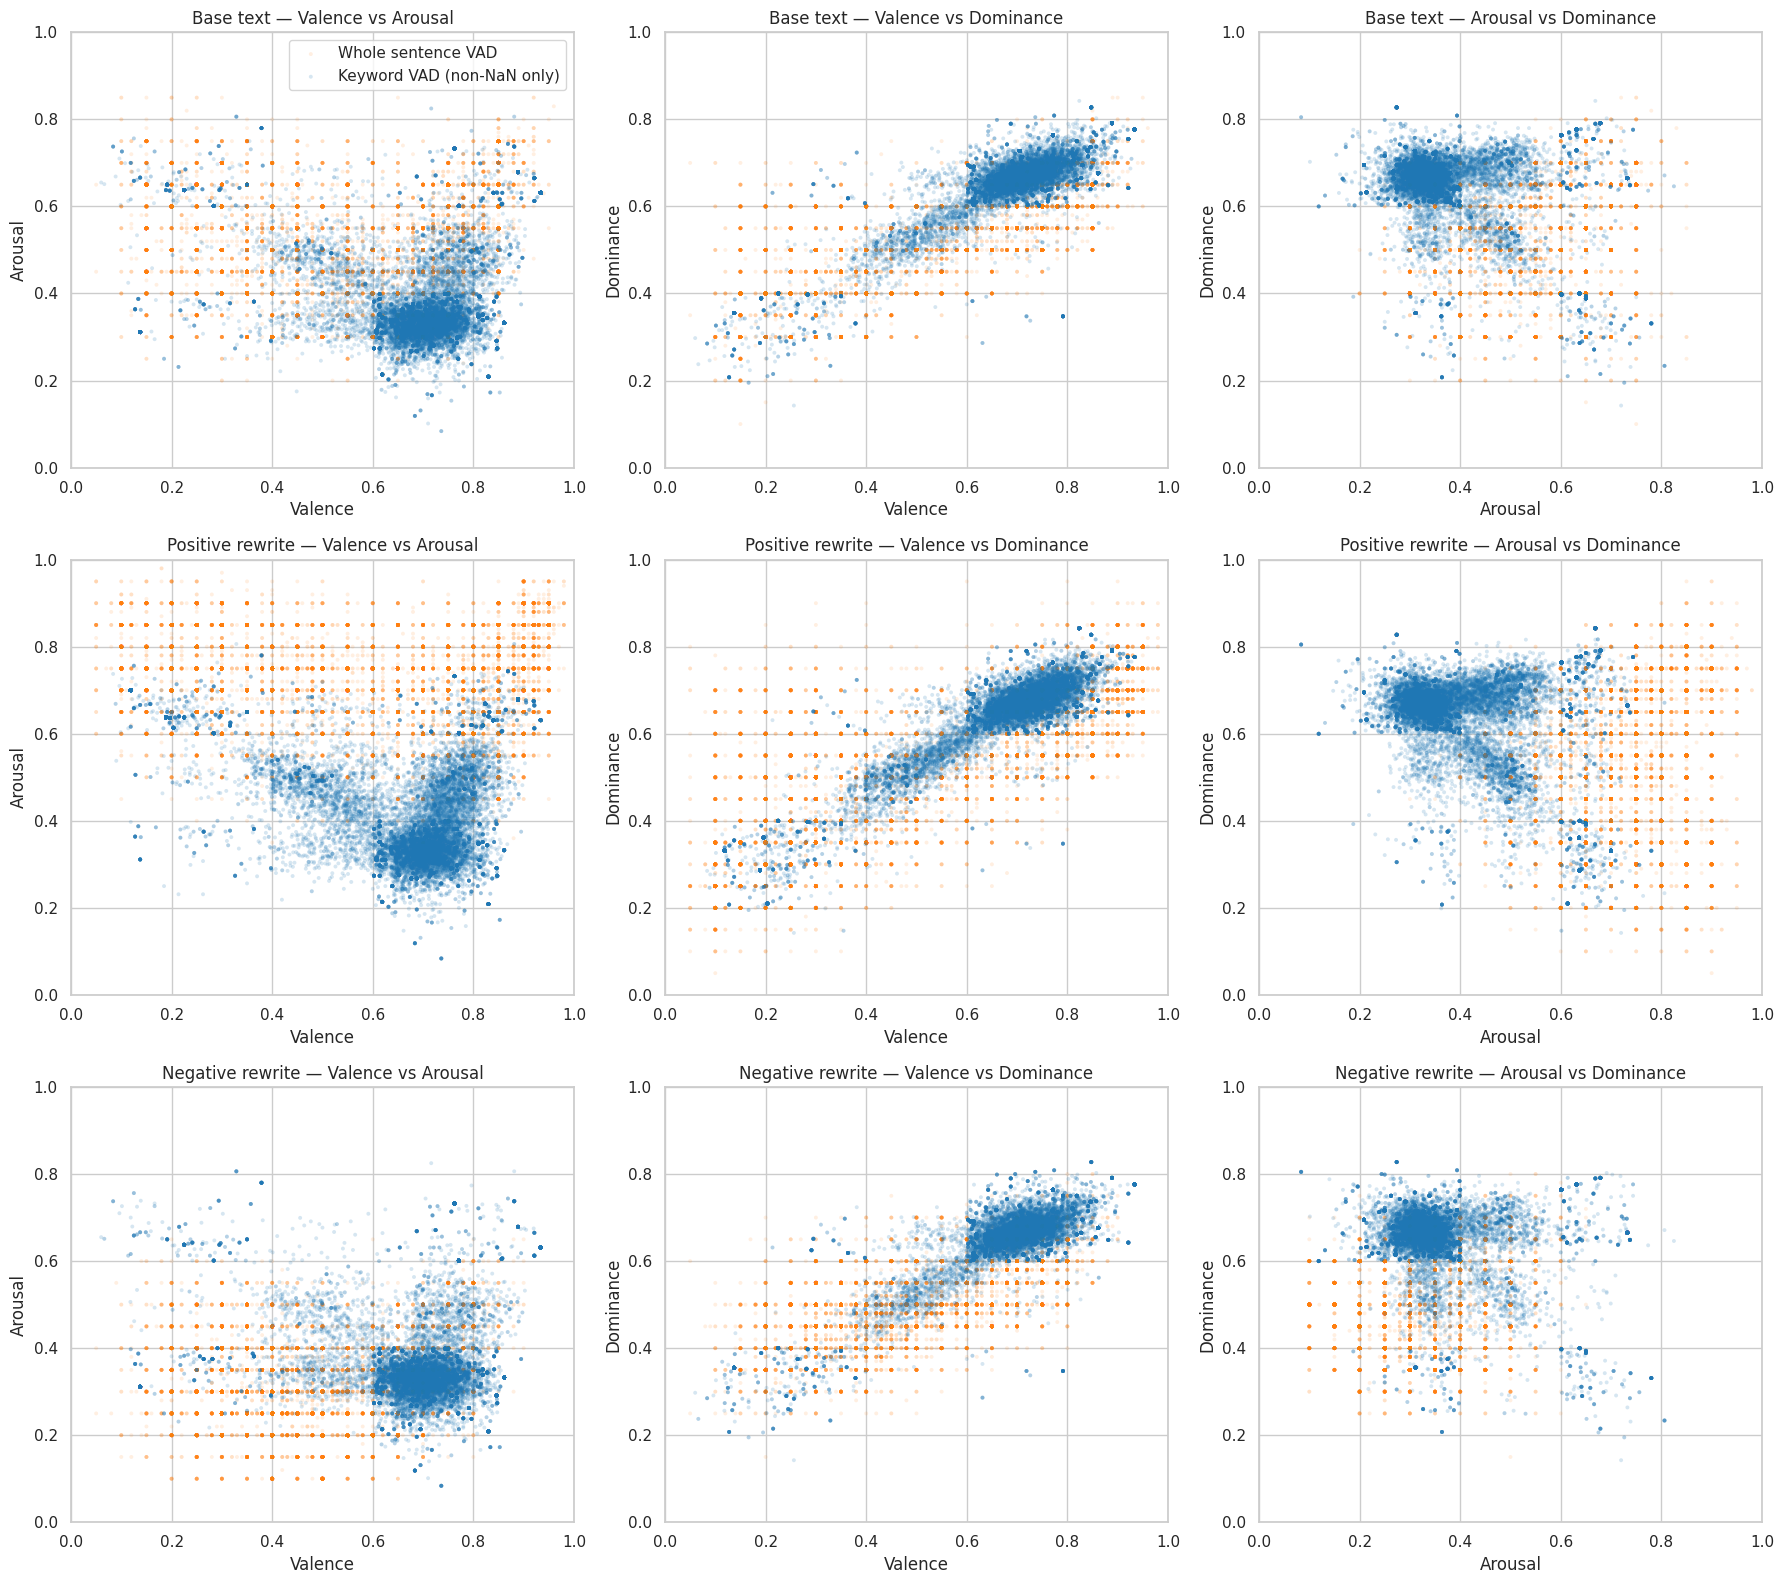

In [7]:
plot_configs = [
    ("base_kw", "Base text", "base"),
    ("positive_kw", "Positive rewrite", "positive"),
    ("negative_kw", "Negative rewrite", "negative"),
]

axis_pairs = [
    ("valence", "arousal", "Valence vs Arousal"),
    ("valence", "dominance", "Valence vs Dominance"),
    ("arousal", "dominance", "Arousal vs Dominance"),
]

fig, axes = plt.subplots(len(plot_configs), len(axis_pairs), figsize=(18, 16))

for row_idx, (prefix, row_title, src) in enumerate(plot_configs):
    for col_idx, (x_dim, y_dim, pair_title) in enumerate(axis_pairs):
        ax = axes[row_idx, col_idx]

        x_col = f"{prefix}_{x_dim}"
        y_col = f"{prefix}_{y_dim}"
        sent_x_col = f"{src}_{x_dim}"
        sent_y_col = f"{src}_{y_dim}"

        # Skip NaN keyword VAD points
        kw_df = df[[x_col, y_col]].dropna()

        # Whole-sentence VAD points
        sent_df = df[[sent_x_col, sent_y_col]].dropna()

        ax.scatter(
            sent_df[sent_x_col],
            sent_df[sent_y_col],
            s=8,
            alpha=0.12,
            color="tab:orange",
            edgecolors="none",
            label="Whole sentence VAD" if (row_idx == 0 and col_idx == 0) else None,
        )

        ax.scatter(
            kw_df[x_col],
            kw_df[y_col],
            s=8,
            alpha=0.18,
            color="tab:blue",
            edgecolors="none",
            label="Keyword VAD (non-NaN only)" if (row_idx == 0 and col_idx == 0) else None,
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel(x_dim.capitalize())
        ax.set_ylabel(y_dim.capitalize())
        ax.set_title(f"{row_title} — {pair_title}")

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="best")

plt.tight_layout()
plt.show()